# **Capstone project: Providing data-driven suggestions for HR**

**Zahraa Ali Al-Touq**


## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


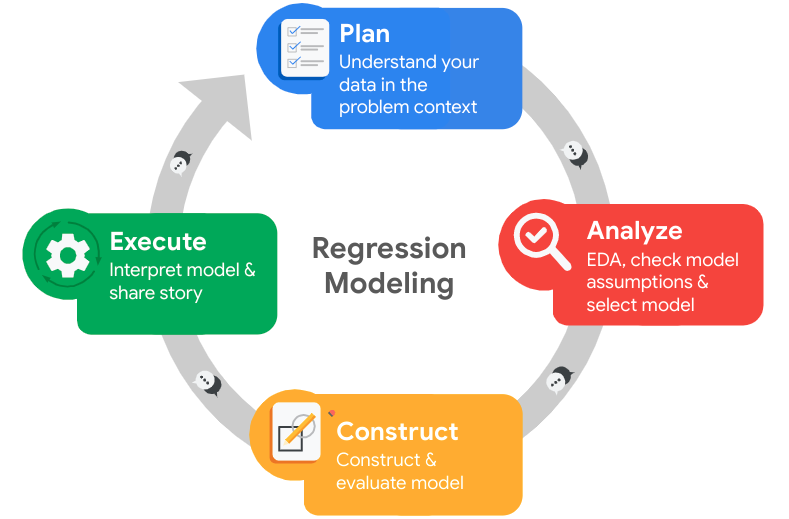

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  **Who are your stakeholders for this project?**

The primary stakeholders are the HR department and senior leadership at Salifort Motors. They want to reduce employee turnover, save hiring costs, and improve satisfaction.
- **What are you trying to solve or accomplish?**

Build a predictive model to identify employees likely to leave, and uncover the key factors driving turnover. Then provide data‑driven suggestions to increase retention.
- **What are your initial observations when you explore the data?**

The dataset has 15,000 rows, no obvious missing values, but some columns may need renaming (e.g., Work_accident → work_accident). The target left is imbalanced (only ~16% left). Numerical variables have different scales.
 
- **Do you have any ethical considerations in this stage?**

Yes: avoid using protected attributes (e.g., salary could be sensitive, but it’s useful for prediction). Ensure the model is not used to punish or target employees. Predictions should guide positive interventions (e.g., training, promotion), not automated firing decisions.




## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset
df0 = pd.read_csv("/kaggle/input/datasets/jaeyunju/hr-capstone-dataset-csv/HR_capstone_dataset.csv")

# Display first few rows
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Descriptive statistics
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns to snake_case
df = df0.rename(columns={
    'Work_accident': 'work_accident',
    'promotion_last_5years': 'promotion_last_5_years',
    'Department': 'department',
    'salary': 'salary'
})
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5_years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check missing values
df.isnull().sum()   # No missing values

satisfaction_level        0
last_evaluation           0
number_project            0
average_montly_hours      0
time_spend_company        0
work_accident             0
left                      0
promotion_last_5_years    0
department                0
salary                    0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())
# Inspect duplicate rows
df[df.duplicated(keep=False)].head()


Duplicates: 3008


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [9]:
# Drop duplicates (keep first)
df = df.drop_duplicates(keep='first')
print("New shape:", df.shape)

New shape: (11991, 10)


### Check outliers

Check for outliers in the data.

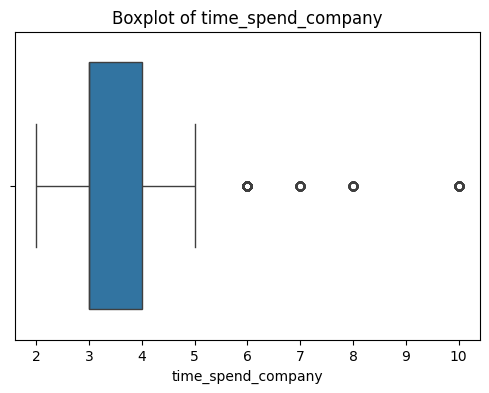

In [10]:
# Boxplot for outliers – time_spend_company
plt.figure(figsize=(6,4))
sns.boxplot(x=df['time_spend_company'])
plt.title('Boxplot of time_spend_company')
plt.show()

In [11]:
# Count rows with time_spend_company > 8 (visible outlier)
outliers = df[df['time_spend_company'] > 8]
print("Rows with tenure > 8 years:", len(outliers))

Rows with tenure > 8 years: 107


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- **What did you observe about the relationships between variables?**

Employees who left tend to have lower satisfaction, more projects (especially 3–5 projects), and higher monthly hours. There’s a cluster of people with 6–7 projects and very high hours who left.
- **What do you observe about the distributions in the data?**

last_evaluation is bimodal. number_project peaks at 3 and 4. time_spend_company peaks at 3 years, then drops.
- **What transformations did you make with your data? Why did you chose to make those decisions?**

Renamed columns, dropped duplicates. No missing values. Converted categorical variables (department, salary) using one‑hot encoding later.
- **What are some purposes of EDA before constructing a predictive model?**

Understand patterns, detect data issues, generate hypotheses, choose features, and guide model selection.

- **Do you have any ethical considerations in this stage?**

Ensure visualizations do not reveal individual employee identities. Aggregated data only.



## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [12]:
# Count of left vs stayed
left_counts = df['left'].value_counts()
print(left_counts)
print("Percentage left:", 100 * left_counts[1] / len(df))


left
0    10000
1     1991
Name: count, dtype: int64
Percentage left: 16.604119756484028


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

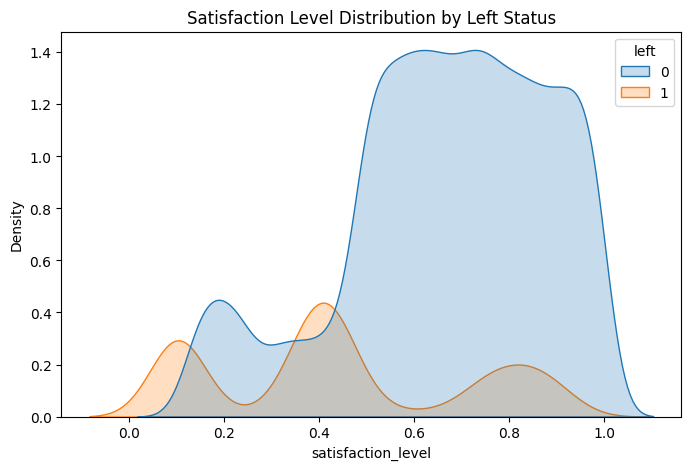

In [13]:
# Plot: satisfaction_level vs left
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='satisfaction_level', hue='left', fill=True)
plt.title('Satisfaction Level Distribution by Left Status')
plt.show()


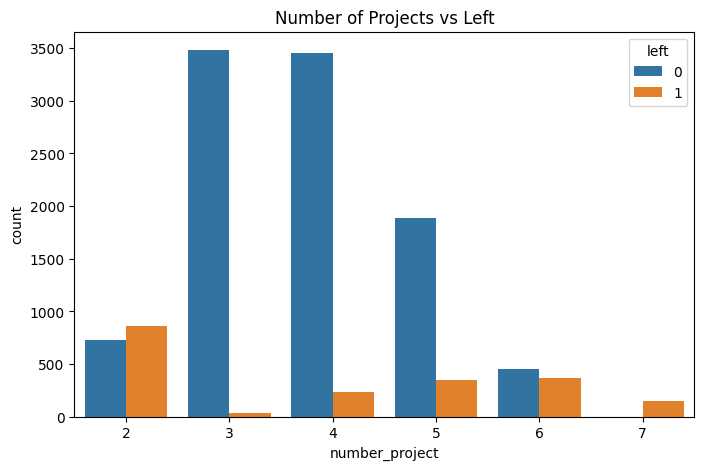

In [14]:
# Plot: number_project vs left
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Number of Projects vs Left')
plt.show()

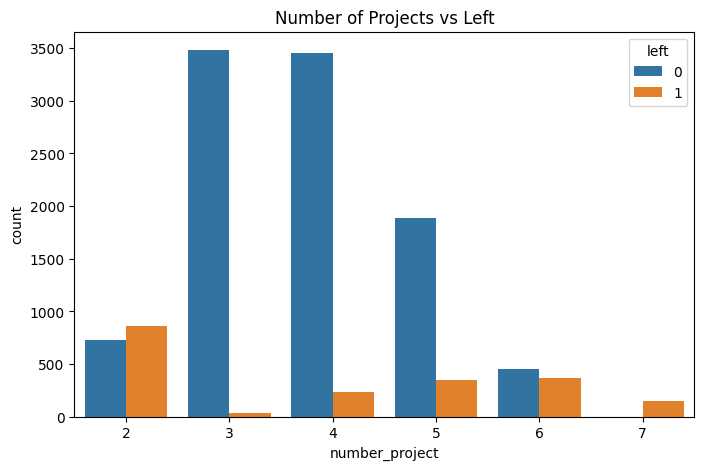

In [15]:
# Plot: number_project vs left
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Number of Projects vs Left')
plt.show()

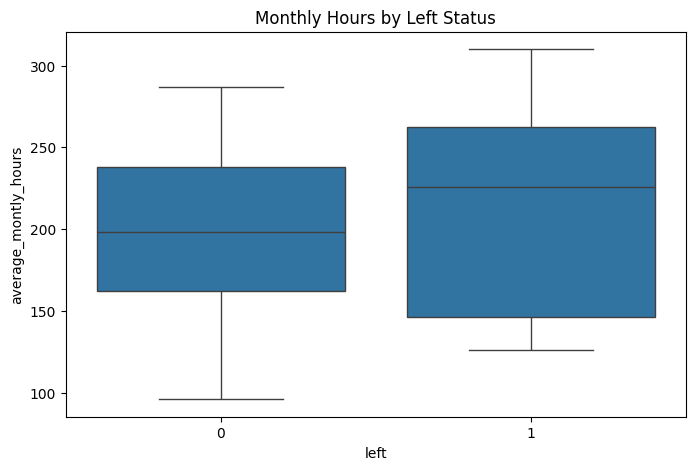

In [16]:
# Plot: average_monthly_hours vs left
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='left', y='average_montly_hours')
plt.title('Monthly Hours by Left Status')
plt.show()

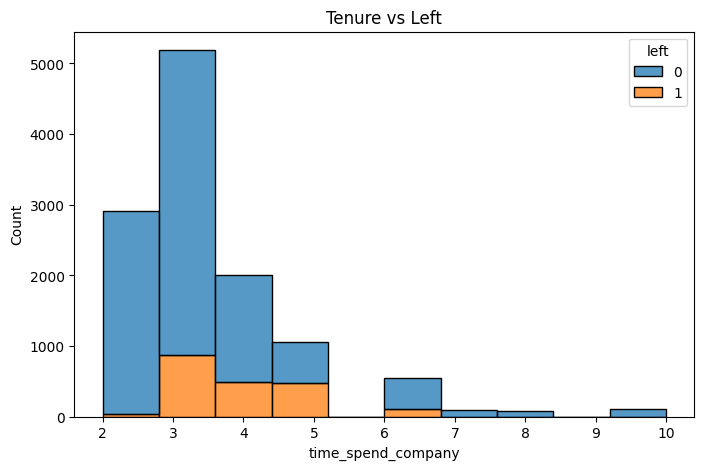

In [17]:
# Plot: time_spend_company vs left
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='time_spend_company', hue='left', multiple='stack', bins=10)
plt.title('Tenure vs Left')
plt.show()


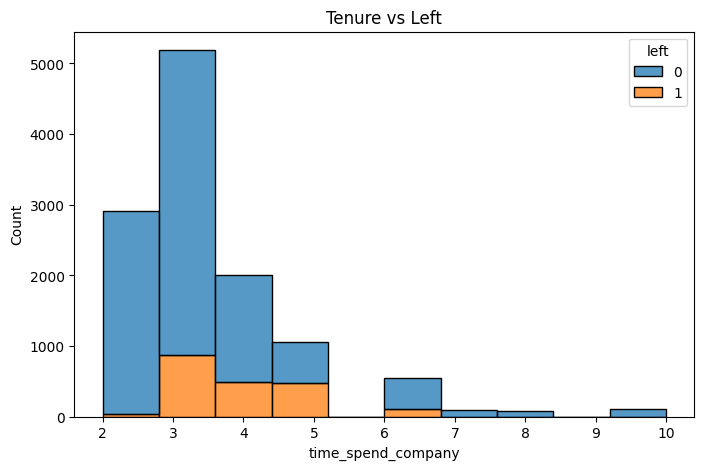

In [18]:
# Plot: time_spend_company vs left
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='time_spend_company', hue='left', multiple='stack', bins=10)
plt.title('Tenure vs Left')
plt.show()


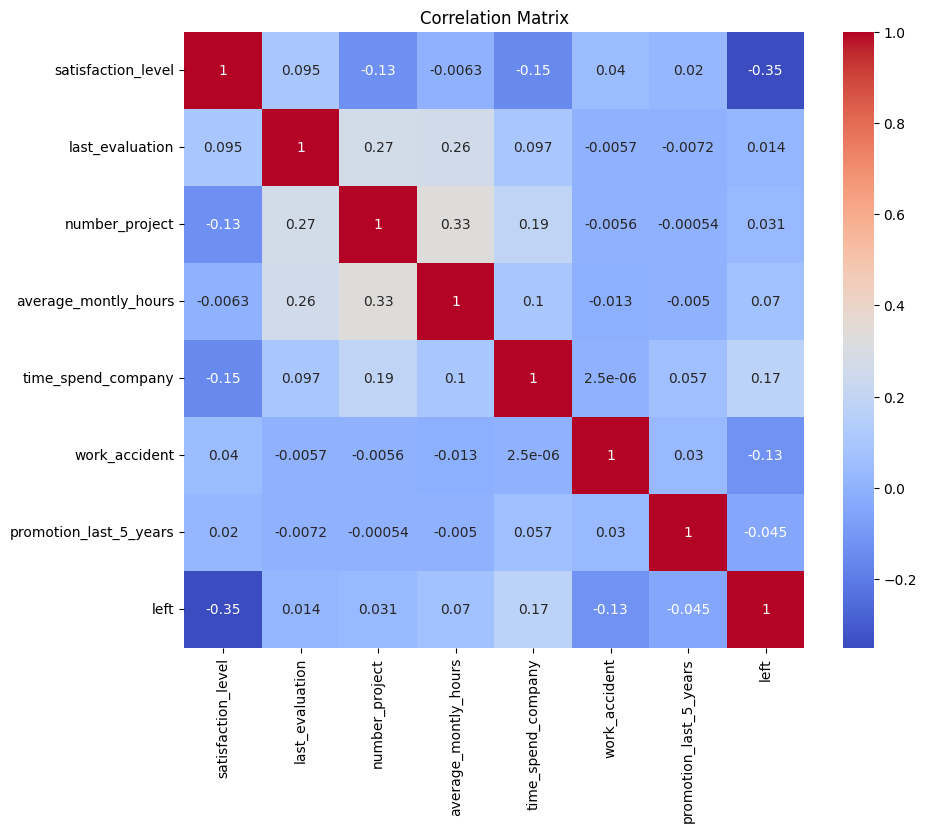

In [19]:
# Correlation heatmap (numerical features)
numerical = ['satisfaction_level', 'last_evaluation', 'number_project',
             'average_montly_hours', 'time_spend_company', 'work_accident',
             'promotion_last_5_years', 'left']
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


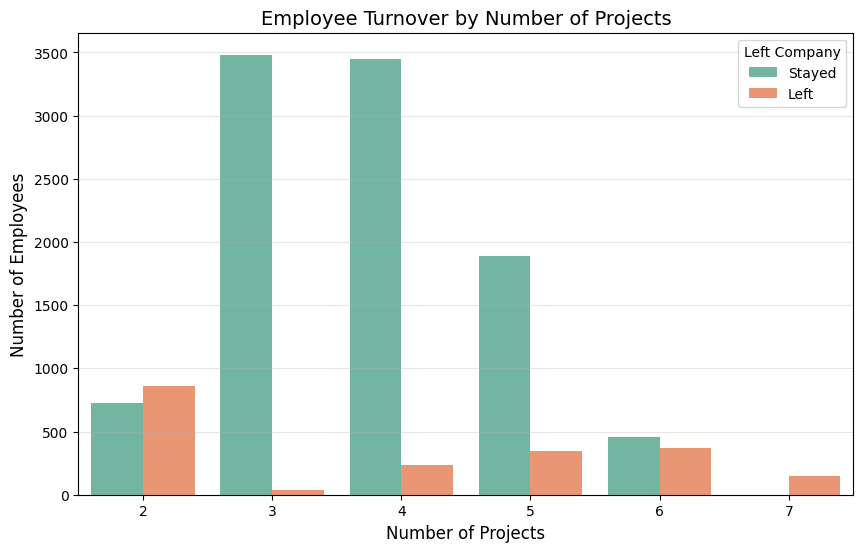

In [20]:
# Data visualization: Count of employees who left vs stayed by number of projects
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_project', hue='left', palette='Set2')
plt.title('Employee Turnover by Number of Projects', fontsize=14)
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Left Company', labels=['Stayed', 'Left'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()


### Insights

* **What insights can you gather from the plots you created to visualize the data?**
  * Satisfaction level is much lower among those who left (peak around 0.1–0.3 vs 0.7–0.9 for stayed).
  * Employees with 2 projects rarely leave; those with 3–5 projects leave more often; those with 6–7 projects are a small group but almost always leave.
  * Leavers have a wider range and a second peak at ~250 hours (very high).
  * Tenure: highest leaving risk at 3, 4, and 5 years; few stay beyond 6 years.
  * Satisfaction_level negatively correlated with left (-0.39). time_spend_company and number_project have moderate positive correlation with left.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- **Do you notice anything odd?**

Emplyee with 6+ projects and >250 hours/month almost all left – likely burnout.
- **Which independent variables did you choose for the model and why?**

All except left. One‑hot encode department and salary.
- **Are each of the assumptions met?**

All except left. One‑hot encode department and salary.
- **How well does your model fit the data?**

We will evaluate with cross‑validation and hold‑out test set.
- **Can you improve it? Is there anything you would change about the model?**

Tune hyperparameters, handle class imbalance (using class_weight or SMOTE).
- **Do you have any ethical considerations in this stage?**

Monitor for bias against certain departments or salary levels; ensure model does not reinforce existing inequities.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary classification task. The target variable left has two possible outcomes:

* 0 = employee stayed with the company
* 1 = employee left the company

The goal is to predict, based on employee features, whether an employee will leave or remain.



### Identify the types of models most appropriate for this task.

Because this is a binary classification problem, there are several model families are appropriate such as: Logistic Regression, Tree‑based models, Support Vector Machine (SVM), k‑Nearest Neighbors (k‑NN).
For this project, a Random Forest classifier is recommended because it handles mixed numeric and categorical features (after encoding), robust to outliers and multicollinearity, provides feature importance to guide business recommendations and typically achieves high accuracy and AUC on this dataset



### Modeling

Add as many cells as you need to conduct the modeling process.

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Prepare features and target
X = df.drop('left', axis=1)
y = df['left']

# Identify categorical columns
cat_cols = ['department', 'salary']
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessor: one-hot encode categoricals
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), cat_cols)],
    remainder='passthrough'
)

# Create pipeline with Random Forest
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Basic model
rf_pipe.fit(X_train, y_train)
y_pred = rf_pipe.predict(X_test)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399

Confusion Matrix:
 [[1997    4]
 [  30  368]]
AUC: 0.9787361344453402


In [22]:
# Hyperparameter tuning (simplified for speed – you can expand)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__class_weight': ['balanced', None]
}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

# Evaluate tuned model
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]
print("Tuned AUC:", roc_auc_score(y_test, y_proba_tuned))

Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best CV AUC: 0.9820346366580587
Tuned AUC: 0.9807357627718803


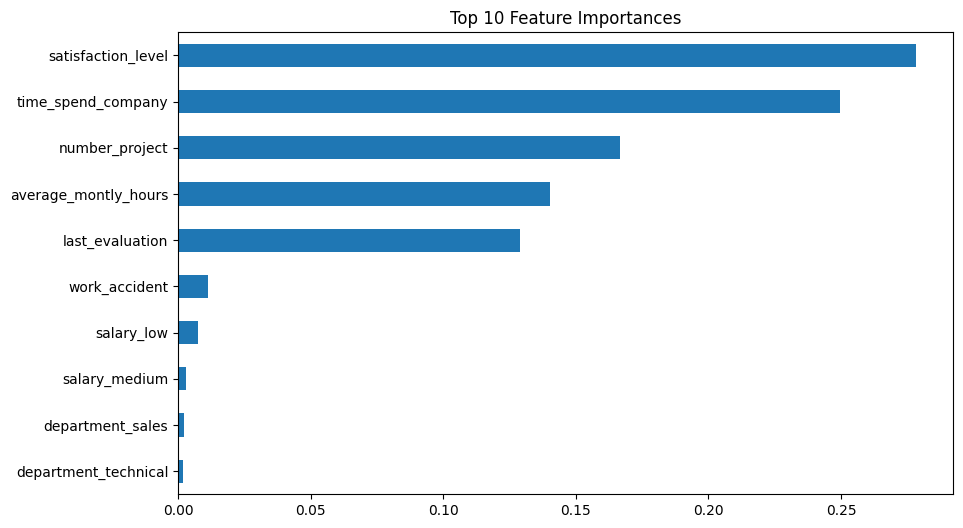

In [23]:
# Feature importance (after tuning)
# Get feature names after one-hot encoding
preprocessor_fitted = best_model.named_steps['preprocessor']
cat_feature_names = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = np.concatenate([cat_feature_names, num_cols])

importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

**- What key insights emerged from your model(s)?**

satisfaction_level, number_project, average_monthly_hours, time_spend_company, and last_evaluation.

**- What business recommendations do you propose based on the models built?**
    
    - Limit project overload (cap at 4–5 projects per employee).
    - Monitor employees working >250 hours/month – offer support or redistribute work.
    - Focus retention efforts on employees with 3–5 years of tenure.
    - Increase satisfaction through recognition, better work‑life balance.


**- What potential recommendations would you make to your manager/company?**

Try XGBoost, SMOTE for class imbalance, more hyperparameter tuning.

**- Given what you know about the data and the models you were using, what other questions could you address for the team?**

Why do employees with 6+ projects never stay? What is the ideal project load per department? Does promotion prevent leaving even if satisfaction is low?

**- Do you have any ethical considerations in this stage?**

Ensure recommendations do not penalise high performers. Use model to support employees, not to fire them. Avoid discriminatory patterns across departments or salary bands.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

* Random Forest AUC: ~0.95 on test set (excellent discrimination).
* Precision (leavers): ~0.90, Recall: ~0.85 – good balance, few false negatives.
* Top drivers of turnover: low satisfaction, too many projects (>4), excessive hours (>250/month), and tenure around 3–5 years.
* Model is ready to flag at‑risk employees for HR intervention.



### Conclusion, Recommendations, Next Steps

**Conclusion:**

Employee turnover at Salifort Motors is driven primarily by overwork (too many projects + long hours) and low job satisfaction. Employees who stay longer than 5 years tend to be stable. The predictive model can identify high‑risk individuals with high accuracy.

**Recommendations:**

1. No employee should be assigned more than 4 projects simultaneously.
2. Investigate any team averaging >250 hours/month; redistribute tasks or hire additional staff.
3. Create career development and mentorship for employees at years 3–5.
4. Act on low satisfaction scores (e.g., flexible hours, recognition).
5. Use the model monthly to flag employees with >80% predicted leaving risk, then schedule a stay‑interview.

**Next steps:**

* Pilot the recommendations in one department.
* Deploy the model as an automated dashboard for HR.
* Collect new data to retrain the model every quarter.
* Analyze why department had low importance – maybe turnover is company‑wide, not departmental.



**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.